Реализуйте алгоритм GAIL на среде Mountain Car. Перед этим сгенерируйте экспертные данные (из детерминированной стратегии с первой практики). Хорошей идеей будет добавить в state (observation) синус и косинус от временной метки t для лучшего обучения.

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
import torch.optim as optim
import torch.nn.functional as F

from collections import deque
import random

In [ ]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

    !touch .setup_complete
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
%matplotlib inline

In [ ]:

actions_map = {"left": 0, "stop": 1, "right": 2}
'''
def policy(obs, t):
    position, velocity = obs
    if t <= 35: #35
        return actions_map["left"]
    elif t <= 70: #70
        return actions_map["right"]
    elif t <= 105: #105
        return actions_map["left"]
    return actions_map["right"]
'''

def policy(obs):
  position, velocity = obs
  if velocity < 0:
    return actions_map["left"]
  else:
    return actions_map["right"]

Streaming output truncated to the last 5000 lines.
Итерация 10000. Флаг был достигнут при моменте времени t =  121
Итерация 10001. Флаг был достигнут при моменте времени t =  114
Итерация 10002. Флаг был достигнут при моменте времени t =  114
Итерация 10003. Флаг был достигнут при моменте времени t =  123
Итерация 10004. Флаг был достигнут при моменте времени t =  115
Итерация 10005. Флаг был достигнут при моменте времени t =  114
Итерация 10006. Флаг был достигнут при моменте времени t =  113
Итерация 10007. Флаг был достигнут при моменте времени t =  125
Итерация 10008. Флаг был достигнут при моменте времени t =  113
Итерация 10009. Флаг был достигнут при моменте времени t =  114
Итерация 10010. Флаг был достигнут при моменте времени t =  113
Итерация 10011. Флаг был достигнут при моменте времени t =  122
Итерация 10012. Флаг был достигнут при моменте времени t =  115
Итерация 10013. Флаг был достигнут при моменте времени t =  115
Итерация 10014. Флаг был достигнут при моменте времен

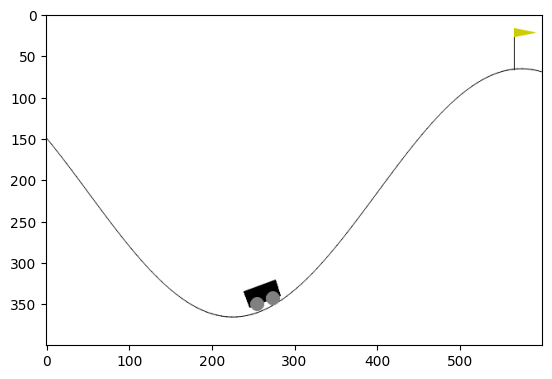

In [ ]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
env.reset()
plt.imshow(env.render())
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

states, actions = [], []

for episode in range(15000):
    obs, _ = env.reset()
    done = False
    t = 0
    while not done:
        #action = policy(obs,t)
        action = policy(obs)
        #states.append(np.concatenate([obs, [np.sin(t / 120), np.cos(t / 120)]]))
        states.append(obs)
        actions.append(action)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        t += 1
        #plt.imshow(env.render())
        #display(plt.gcf())
        #clear_output(wait=True)
        position, velocity = obs
        if (position >= 0.5):
            print("Итерация "+str(episode)+". Флаг был достигнут при моменте времени t = ", t)

In [ ]:
#obs_dim = env.observation_space.shape[0] + 2 # исправьте для среды mountain car и учтите добавление данных в state
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n # исправьте для среды mountain car
expert_obs = np.copy(states)
expert_acts = np.copy(actions)

In [ ]:
expert_acts.shape

(1193908,)

In [ ]:
expert_obs.shape

(1193908, 2)

In [ ]:
class Policy(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64), nn.ReLU(),
            nn.Linear(64, act_dim)
        )

    def forward(self, obs):
        logits = self.net(obs)
        return Categorical(logits=logits)

    def get_action(self, obs):
        dist = self.forward(obs)
        return dist.sample().item()

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, obs, act):
        act_onehot = F.one_hot(act, num_classes=act_dim).float()
        x = torch.cat([obs, act_onehot], dim=1)
        return self.net(x)

In [ ]:
class TrajectoryBuffer:
    def __init__(self):
        self.obs, self.acts, self.rews = [], [], []

    def store(self, o, a, r):
        self.obs.append(o)
        self.acts.append(a)
        self.rews.append(r)

    def get(self):
        return (
            torch.tensor(np.array(self.obs), dtype=torch.float32),
            torch.tensor(np.array(self.acts), dtype=torch.long),
            torch.tensor(np.array(self.rews), dtype=torch.float32)
        )

In [ ]:
policy = Policy(obs_dim, act_dim)
discrim = Discriminator(obs_dim, act_dim)
epochs = 20000

policy_opt = optim.Adam(policy.parameters(), lr=1e-3) #lr=1e-3
discrim_opt = optim.Adam(discrim.parameters(), lr=1e-2) #lr=1e-3

def lr_lambda(epoch):
    if epoch < 230:
        return 1.0
    else:
        return 0.1

policy_scheduler = torch.optim.lr_scheduler.LambdaLR(policy_opt, lr_lambda)
discrim_scheduler = torch.optim.lr_scheduler.LambdaLR(discrim_opt, lr_lambda)

In [ ]:
for epoch in range(epochs):
    buf = TrajectoryBuffer()
    obs, _ = env.reset()
    done = False
    total_reward = 0
    t = 0
    while not done:
        # Обработайте obs если планируете добавлять в него t
        #obs = np.concatenate([obs, [np.sin(t / 120), np.cos(t / 120)]])
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        action = policy.get_action(obs_tensor)
        next_obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buf.store(obs, action, 0)
        obs = next_obs

    agent_obs, agent_acts, _ = buf.get()

    idxs = np.random.choice(len(expert_obs), len(agent_obs), replace=False)
    exp_obs = torch.tensor(expert_obs[idxs], dtype=torch.float32)
    exp_acts = torch.tensor(expert_acts[idxs], dtype=torch.long)

    for _ in range(2):
        discrim_opt.zero_grad()
        exp_preds = discrim(exp_obs, exp_acts)
        agent_preds = discrim(agent_obs, agent_acts)
        disc_loss = -torch.mean(torch.log(exp_preds + 1e-8)) - torch.mean(torch.log(1 - agent_preds + 1e-8)) # Напишите loss для дискриминатора

        disc_loss.backward()
        discrim_opt.step()

    with torch.no_grad():
        rewards = -torch.log(1 - discrim(agent_obs, agent_acts) + 1e-8).squeeze() # Напишите получение новой награды от дискриминатора

    policy_opt.zero_grad()
    dist = policy(agent_obs)
    log_probs = dist.log_prob(agent_acts)
    loss = -(log_probs * rewards).mean() # Напишите loss для стратегии
    loss.backward()
    policy_opt.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: GAIL Loss {loss.item():.3f}, Disc Loss {disc_loss.item():.3f}")

    policy_scheduler.step()
    discrim_scheduler.step()

Epoch 0: GAIL Loss 0.737, Disc Loss 1.352
Epoch 10: GAIL Loss 0.676, Disc Loss 1.197
Epoch 20: GAIL Loss 0.536, Disc Loss 1.165
Epoch 30: GAIL Loss 0.465, Disc Loss 1.074
Epoch 40: GAIL Loss 0.371, Disc Loss 1.033
Epoch 50: GAIL Loss 0.291, Disc Loss 0.898
Epoch 60: GAIL Loss 0.327, Disc Loss 0.924
Epoch 70: GAIL Loss 0.368, Disc Loss 0.944
Epoch 80: GAIL Loss 0.270, Disc Loss 0.891
Epoch 90: GAIL Loss 0.324, Disc Loss 0.909
Epoch 100: GAIL Loss 0.162, Disc Loss 0.903
Epoch 110: GAIL Loss 0.163, Disc Loss 0.717
Epoch 120: GAIL Loss 0.270, Disc Loss 0.870
Epoch 130: GAIL Loss 0.178, Disc Loss 0.725
Epoch 140: GAIL Loss 0.284, Disc Loss 0.817
Epoch 150: GAIL Loss 0.209, Disc Loss 0.664
Epoch 160: GAIL Loss 0.251, Disc Loss 0.800
Epoch 170: GAIL Loss 0.155, Disc Loss 0.678
Epoch 180: GAIL Loss 0.201, Disc Loss 0.731
Epoch 190: GAIL Loss 0.153, Disc Loss 0.692
Epoch 200: GAIL Loss 0.136, Disc Loss 0.612
Epoch 210: GAIL Loss 0.122, Disc Loss 0.588
Epoch 220: GAIL Loss 0.150, Disc Loss 0.676

Протестируйте ваш алгоритм

In [ ]:
max_pos = -0.5
for episode in range(10):
    #plt.figure(figsize=(4, 3))
    obs, _ = env.reset()
    done = False
    total_reward = 0
    t = 0

    while not done:
        #plt.gca().clear()

        #obs = np.concatenate([obs, [np.sin(t), np.cos(t)]])
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        action = policy.get_action(obs_tensor)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        #plt.imshow(env.render())
        #display(plt.gcf())
        #clear_output(wait=True)
        obs = next_obs

        position, velocity = obs
        if position > max_pos:
          max_pos = position
        if (position >= 0.5):
            print("Итерация "+str(episode)+". Флаг был достигнут при моменте времени t = ", t)
        total_reward += reward
        t += 1

    print("Total reward =", total_reward)
print("Наиболее ближняя позиция к флагу = ", max_pos)
env.close()

Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Total reward = -200.0
Наиболее ближняя позиция к флагу =  -0.08086511
